In [2]:
import pickle
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

In [32]:
n_probes = 100
n_channels = 64
sim_flag = 'probes'

sim_dir = '/home/kedoxey/PyramidalCellSimulations/models/NEURON/NMLCL000073-NEURON/output/LFP_basal'
sim_label = f'LFP_basal-0nA-50Ex1-1x40Hz-{n_probes}x{n_channels}lp-{sim_flag}'


eap_file_path = os.path.join(sim_dir, sim_label, f'{sim_label}-simulated_eaps.pkl')
probe_file_path = os.path.join(sim_dir, sim_label, f'{sim_label}-recording_probe_locs.pkl')

In [33]:
data_df = pd.read_pickle(eap_file_path)
probes = np.array(pd.read_pickle(probe_file_path))

In [34]:
num_probes, num_channels, _ = np.shape(probes)

probe_nums = []
channel_nums = []

for i, row in data_df.iterrows():
    probe_nums.append(int(i/num_channels))
    channel_nums.append(i%num_channels)

data_df['probe_num'] = probe_nums
data_df['channel_num'] = channel_nums

In [35]:
data_df.head()

,Model_ID,t,vm,ve,x_bar,y_bar,z_bar,num_spikes,did_spike,first_spkt,probe_num,channel_num
0,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[1.4683155998794908e-05, 1.4683033719120108e-0...",4.788917,-317.117009,15.918493,1147,True,408.071733,0,0
1,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[1.7234130407982727e-05, 1.7234009139822218e-0...",4.788917,-307.117009,15.918493,1147,True,408.071733,0,1
2,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[1.9768643569360802e-05, 1.9768523109521328e-0...",4.788917,-297.117009,15.918493,1147,True,408.071733,0,2
3,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[2.229151647911385e-05, 2.2291396496642475e-05...",4.788917,-287.117009,15.918493,1147,True,408.071733,0,3
4,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[2.4816832935173393e-05, 2.4816713131216955e-0...",4.788917,-277.117009,15.918493,1147,True,408.071733,0,4


In [36]:
def find_n_closest_probes(probes, n_closest, max_channel_i = 25):
    
    num_probes, _, _ = np.shape(probes)
    distances = []
    
    for i in range(num_probes):
        probe = probes[i,:,:]
        x,y,z = probe[max_channel_i]
        dist = np.sqrt(x**2+y**2+z**2)
        distances.append(dist)
        
    print('Closest probe found at %s microns...'%np.min(distances))
    return np.argsort(distances)[:n_closest]  # np.argmin(distances)

def find_n_farthest_probes(probes, n_farthest, max_channel_i = 25):
    
    num_probes, _, _ = np.shape(probes)
    distances = []
    
    for i in range(num_probes):
        probe = probes[i,:,:]
        x,y,z = probe[max_channel_i]
        dist = np.sqrt(x**2+y**2+z**2)
        distances.append(dist)
        
    print('Farthest probe found at %s microns...'%np.max(distances))
    return np.argsort(distances)[-n_farthest:]  # np.argmax(distances)

In [37]:
closest_probe = find_n_closest_probes(probes, n_probes//2, max_channel_i=n_channels//2)
closest_probe_df = data_df[data_df.probe_num.isin(closest_probe)]
closest_probe_df.head()

Closest probe found at 11.176532159151513 microns...


,Model_ID,t,vm,ve,x_bar,y_bar,z_bar,num_spikes,did_spike,first_spkt,probe_num,channel_num
0,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[1.4683155998794908e-05, 1.4683033719120108e-0...",4.788917,-317.117009,15.918493,1147,True,408.071733,0,0
1,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[1.7234130407982727e-05, 1.7234009139822218e-0...",4.788917,-307.117009,15.918493,1147,True,408.071733,0,1
2,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[1.9768643569360802e-05, 1.9768523109521328e-0...",4.788917,-297.117009,15.918493,1147,True,408.071733,0,2
3,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[2.229151647911385e-05, 2.2291396496642475e-05...",4.788917,-287.117009,15.918493,1147,True,408.071733,0,3
4,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[2.4816832935173393e-05, 2.4816713131216955e-0...",4.788917,-277.117009,15.918493,1147,True,408.071733,0,4


In [38]:
np.unique(closest_probe_df.probe_num)

array([ 0,  1,  4,  8, 10, 12, 13, 15, 17, 19, 20, 25, 26, 29, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 42, 47, 49, 51, 54, 55, 59, 62, 63, 65,
       68, 69, 70, 71, 75, 76, 78, 80, 85, 87, 89, 92, 93, 94, 97, 99])

In [39]:
avg_waves_close = []

for channel_num in range(num_channels):

    channel_df = closest_probe_df[closest_probe_df.channel_num == channel_num]

    waves = []

    for _, row in channel_df.iterrows():

        ve = row.ve
        amp = np.max(ve) - np.min(ve)
        norm_ve = np.divide(ve, amp)
        wave = list(norm_ve)
        waves.append(wave)

    waves = np.array(waves)
    channel_avg = np.average(waves, 0)

    avg_waves_close.append(channel_avg)

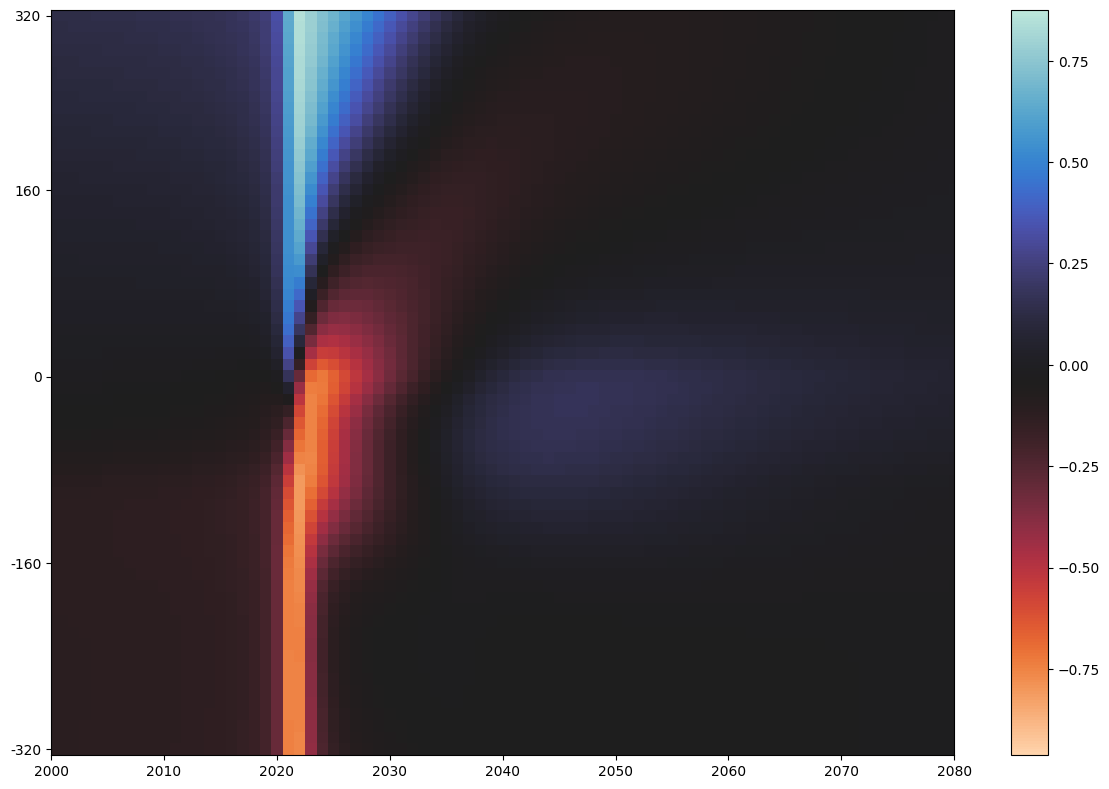

In [40]:
icefire_cmap = sns.color_palette("icefire_r", as_cmap=True)

fig, axs = plt.subplots(1,1, figsize=(12,8))
im = axs.imshow(avg_waves_close, interpolation='nearest', aspect='auto', cmap=icefire_cmap)
axs.set_xlim([2000, 2080])
axs.set_yticks([0, 15, 31, 47, 63])
axs.set_yticklabels([320, 160, 0, -160, -320])
fig.colorbar(im)
fig.tight_layout()
fig.savefig(os.path.join(sim_dir, sim_label, 'closest_probes.png'), dpi=300)

In [41]:
farthest_probe = find_n_farthest_probes(probes, n_probes//2, max_channel_i=n_channels//2)
farthest_probe_df = data_df[data_df.probe_num.isin(farthest_probe)]
farthest_probe_df.head()

Farthest probe found at 32.11033310655298 microns...


,Model_ID,t,vm,ve,x_bar,y_bar,z_bar,num_spikes,did_spike,first_spkt,probe_num,channel_num
128,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[1.3655621947126281e-05, 1.365550295982663e-05...",19.739821,-323.302918,14.702257,1147,True,408.071733,2,0
129,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[1.5973996276141474e-05, 1.597387642205759e-05...",19.739821,-313.302918,14.702257,1147,True,408.071733,2,1
130,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[1.837185264591956e-05, 1.8371732444274937e-05...",19.739821,-303.302918,14.702257,1147,True,408.071733,2,2
131,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[2.0825257878216612e-05, 2.0825137639752336e-0...",19.739821,-293.302918,14.702257,1147,True,408.071733,2,3
132,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[2.33211097541704e-05, 2.332098968637278e-05, ...",19.739821,-283.302918,14.702257,1147,True,408.071733,2,4


In [42]:
np.unique(farthest_probe_df.probe_num)

array([ 2,  3,  5,  6,  7,  9, 11, 14, 16, 18, 21, 22, 23, 24, 27, 28, 30,
       41, 43, 44, 45, 46, 48, 50, 52, 53, 56, 57, 58, 60, 61, 64, 66, 67,
       72, 73, 74, 77, 79, 81, 82, 83, 84, 86, 88, 90, 91, 95, 96, 98])

In [43]:
avg_waves_far = []

for channel_num in range(num_channels):

    channel_df = farthest_probe_df[farthest_probe_df.channel_num == channel_num]

    waves = []

    for _, row in channel_df.iterrows():

        ve = row.ve
        amp = np.max(ve) - np.min(ve)
        norm_ve = np.divide(ve, amp)
        wave = list(norm_ve)
        waves.append(wave)

    waves = np.array(waves)
    channel_avg = np.average(waves, 0)

    avg_waves_far.append(channel_avg)

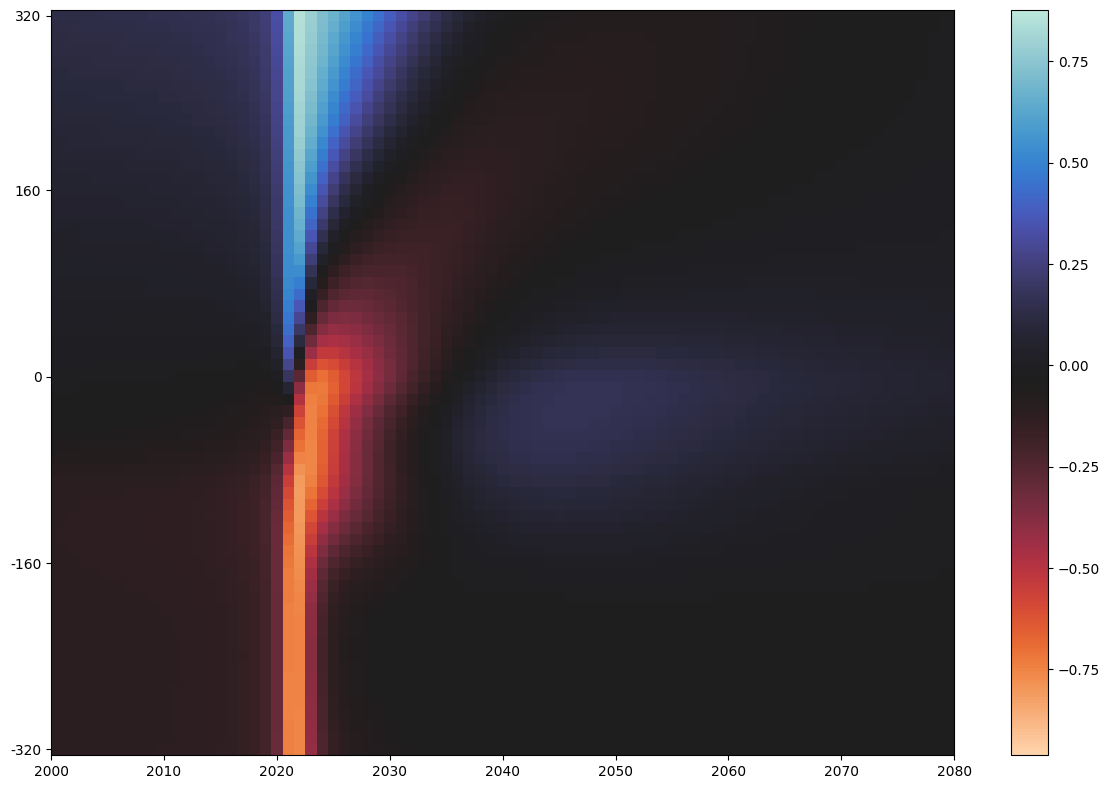

In [44]:
icefire_cmap = sns.color_palette("icefire_r", as_cmap=True)

fig, axs = plt.subplots(1,1, figsize=(12,8))
im = axs.imshow(avg_waves_far, interpolation='nearest', aspect='auto', cmap=icefire_cmap)
axs.set_xlim([2000, 2080])
axs.set_yticks([0, 15, 31, 47, 63])
axs.set_yticklabels([320, 160, 0, -160, -320])
fig.colorbar(im)
fig.tight_layout()
fig.savefig(os.path.join(sim_dir, sim_label, 'farthest_probes.png'), dpi=300)

### Normalize data

<!-- ### Plot heatmap
https://datascience.stackexchange.com/questions/93941/create-a-continuous-heatmap
 -->
